In [1]:
# 1. Import Required Libraries
# ---------------------------

import os
import numpy as np
import rioxarray as rxr
import matplotlib.pyplot as plt

# ---------------------------

Connected to .venv (3.10.12) (Python 3.10.12)

In [2]:
# 2. Define File Paths
# ---------------------------
# Load CORINE raster via rioxarray
corine_path = "/mnt/eo/WilDensity/_data/_corine/CLCplus_2018_010m.tif"
output_dir = "/mnt/eo/WilDensity/output"
os.makedirs(output_dir, exist_ok=True)

# ---------------------------

In [ ]:
# 3. Load CORINE Raster
# ---------------------------
corine_xr = rxr.open_rasterio(corine_path, masked=True).squeeze()
corine_arr = corine_xr.values.copy()

# ---------------------------

In [ ]:
# 4. Define Reclassification Function
# ---------------------------
# Reclassification function
def reclassify(array, rcl_matrix):
    out = np.full_like(array, fill_value=np.nan, dtype=np.float32)
    for from_val, to_val, new_val in rcl_matrix:
        mask = (array >= from_val) & (array <= to_val)
        out[mask] = new_val
    return out

# ---------------------------

In [ ]:
# 5. Define Reclassification Matrices
# ---------------------------
rcl_chamois = np.array([
    [1, 1, 2],
    [2, 5, 1],
    [6, 7, 0],
    [8, 9, 1],
    [10, 10, 2],
    [11, 11, 0]
])

rcl_roe_deer = np.array([
    [1, 1, 2],
    [2, 2, 1],
    [3, 3, 1],
    [4, 4, 1],
    [5, 5, 1],
    [6, 6, 1],
    [7, 7, 1],
    [8, 8, 0],
    [9, 9, 0],
    [10, 10, 2],
    [11, 11, 0]
])

rcl_red_deer = np.array([
    [1, 1, 2],
    [2, 2, 1],
    [3, 3, 1],
    [4, 4, 1],
    [5, 5, 1],
    [6, 6, 0],
    [7, 7, 0],
    [8, 8, 0],
    [9, 9, 0],
    [10, 10, 2],
    [11, 11, 0]
])

reclassifications = {
    "binary_chamois": rcl_chamois,
    "binary_roe_deer": rcl_roe_deer,
    "binary_red_deer": rcl_red_deer
}

# ---------------------------

In [ ]:
# 6. Visualise new rasters
# ---------------------------
# Re-open the saved chamois raster (lazy-loading)
chamois_raster_path = os.path.join(output_dir, "binary_chamois.tif")
chamois_xr = rxr.open_rasterio(chamois_raster_path, masked=True).squeeze()

# Select a spatial subset (e.g., 1000x1000 pixels starting from top-left)
subset = chamois_xr.isel(x=slice(0, 1000), y=slice(0, 1000))  # adapt as needed

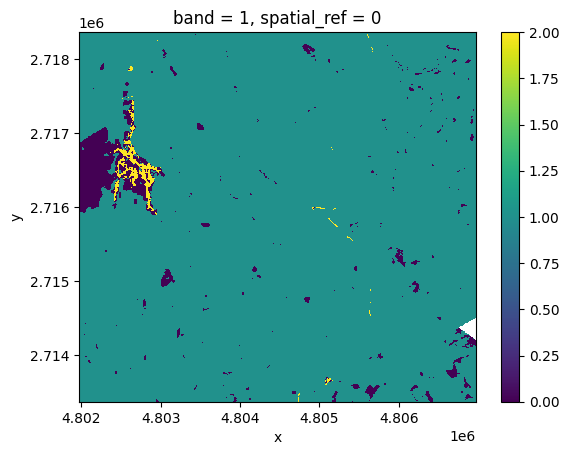

In [ ]:
# 6. Visualise new rasters
# ---------------------------

# Find non-NaN indices
non_nan_mask = ~np.isnan(chamois_xr.values)
non_nan_indices = np.argwhere(non_nan_mask)

# Pick the center of the valid area
center_idx = non_nan_indices[len(non_nan_indices)//2]
y_center, x_center = center_idx

# Define a subset window size (e.g., 500x500)
half_window = 250
x_slice = slice(max(0, x_center - half_window), x_center + half_window)
y_slice = slice(max(0, y_center - half_window), y_center + half_window)

# Subset and plot
subset = chamois_xr.isel(x=x_slice, y=y_slice)
subset.plot(cmap="viridis")